In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

In [2]:


columns = [
    'unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'TRA', 
    'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr', 
    'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'Nf_dmd', 
    'PCNfR_dmd', 'W31', 'W32'
]


print("Building the Mega-Model Dataset...")

datasets = ["FD001", "FD002", "FD003", "FD004"]
all_train, all_test = [], []
offset = 0 


Building the Mega-Model Dataset...


In [3]:
for fd in datasets:
  
    df_tr = pd.read_csv(f"CMaps/train_{fd}.txt", sep=r'\s+', header=None, names=columns).dropna(axis=1, how='all')
    df_te = pd.read_csv(f"CMaps/test_{fd}.txt", sep=r'\s+', header=None, names=columns).dropna(axis=1, how='all')
    rul = pd.read_csv(f"CMaps/RUL_{fd}.txt", sep=r'\s+', header=None).values
    
   
    df_tr['unit_number'] += offset
    df_te['unit_number'] += offset
    
   
    eol_tr = []
    for eng in df_tr['unit_number']:
        eol_tr.append(df_tr[df_tr['unit_number'] == eng]['time_in_cycles'].max())
    df_tr['EOL'] = eol_tr
    df_tr['LR'] = df_tr['time_in_cycles'] / df_tr['EOL']
    
  
    eol_te = []
    for eng in df_te['unit_number']:
        cycles = len(df_te[df_te['unit_number'] == eng])
        actual = rul[(eng - offset) - 1][0]
        eol_te.append(cycles + actual)
    df_te['EOL'] = eol_te
    df_te['LR'] = df_te['time_in_cycles'] / df_te['EOL']
    
    all_train.append(df_tr)
    all_test.append(df_te)
    offset += 1000 

In [4]:
# Stitch everything together into the MEGA dataframes
mega_train_df = pd.concat(all_train, ignore_index=True)
mega_test_df = pd.concat(all_test, ignore_index=True)


In [5]:
mega_train_df.head()

,unit_number,time_in_cycles,setting_1,setting_2,TRA,T2,T24,T30,T50,P2,...,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32,EOL,LR
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,0.005208
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,0.010417
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,0.015625
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,0.020833
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,0.026042


In [6]:
mega_test_df.head()

,unit_number,time_in_cycles,setting_1,setting_2,TRA,T2,T24,T30,T50,P2,...,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32,EOL,LR
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,143,0.006993
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,143,0.013986
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,143,0.020979
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,143,0.027972
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,143,0.034965


In [7]:
def assign_labels(df):
    """Categorizes engine health based on Life Ratio."""
    labels = []
    for lr in df['LR']:
        if lr <= 0.6: labels.append(0)
        elif lr <= 0.8: labels.append(1)
        else: labels.append(2)
    df['labels'] = labels
    return df.drop(columns=['unit_number', 'EOL', 'LR'])

mega_train_model = assign_labels(mega_train_df)
mega_test_model = assign_labels(mega_test_df)

In [8]:
zero_var = mega_train_model.columns[mega_train_model.std() < 0.01]
print("Dropped flatline sensors across all datasets:", list(zero_var))

Dropped flatline sensors across all datasets: ['farB']


In [9]:
mega_train_model = mega_train_model.drop(columns=zero_var)
mega_test_model = mega_test_model.drop(columns=zero_var, errors='ignore')

In [10]:
X_tr_mega = mega_train_model.drop(columns=['labels'])
y_tr_mega = mega_train_model['labels']
X_te_mega = mega_test_model.drop(columns=['labels'])
y_te_mega = mega_test_model['labels']

In [11]:
mega_scaler = StandardScaler()
X_tr_mega_scaled = pd.DataFrame(mega_scaler.fit_transform(X_tr_mega), columns=X_tr_mega.columns)
X_te_mega_scaled = pd.DataFrame(mega_scaler.transform(X_te_mega), columns=X_te_mega.columns)

In [12]:
print(f"\nTraining Mega-Model on {len(X_tr_mega_scaled)} rows... (This might take a few seconds!)")
mega_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
mega_model.fit(X_tr_mega_scaled, y_tr_mega)


Training Mega-Model on 160359 rows... (This might take a few seconds!)


RandomForestClassifier(n_jobs=-1, random_state=42)

In [13]:

y_pred_mega = mega_model.predict(X_te_mega_scaled)
print("\nFinal Mega-Model Accuracy:", accuracy_score(y_te_mega, y_pred_mega))


Final Mega-Model Accuracy: 0.9079477964098115


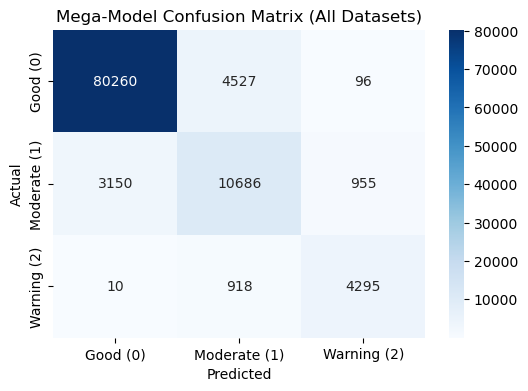

In [14]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_te_mega, y_pred_mega), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Good (0)', 'Moderate (1)', 'Warning (2)'], 
            yticklabels=['Good (0)', 'Moderate (1)', 'Warning (2)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Mega-Model Confusion Matrix (All Datasets)')
plt.show()

In [15]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

print("Imported KNeighborsClassifier and classification_report successfully for Mega-Model.")

Imported KNeighborsClassifier and classification_report successfully for Mega-Model.


In [16]:

print(f"Training KNN Classifier on Mega-Model Dataset ({len(X_tr_mega_scaled)} rows)...\n")
knn_mega = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_mega.fit(X_tr_mega_scaled, y_tr_mega)



Training KNN Classifier on Mega-Model Dataset (160359 rows)...



KNeighborsClassifier(n_jobs=-1)

In [17]:

y_pred_knn_mega = knn_mega.predict(X_te_mega_scaled)
knn_mega_acc = accuracy_score(y_te_mega, y_pred_knn_mega)
print(f"Mega-Model KNN Accuracy: {knn_mega_acc:.6f}")
print("\nClassification Report (Mega-Model KNN):")
print(classification_report(y_te_mega, y_pred_knn_mega, target_names=['Good (0)', 'Moderate (1)', 'Warning (2)']))

Mega-Model KNN Accuracy: 0.885554

Classification Report (Mega-Model KNN):
              precision    recall  f1-score   support

    Good (0)       0.95      0.93      0.94     84883
Moderate (1)       0.59      0.65      0.62     14791
 Warning (2)       0.73      0.76      0.74      5223

    accuracy                           0.89    104897
   macro avg       0.76      0.78      0.77    104897
weighted avg       0.89      0.89      0.89    104897



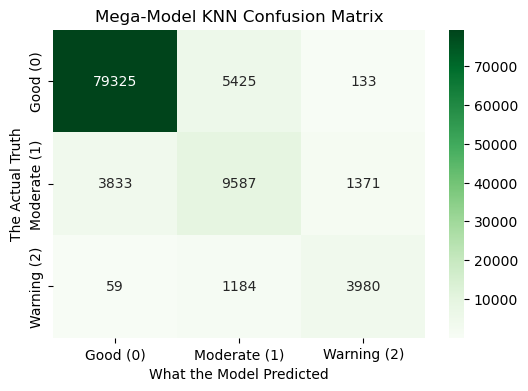

In [18]:

cm_knn_mega = confusion_matrix(y_te_mega, y_pred_knn_mega)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn_mega, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Good (0)', 'Moderate (1)', 'Warning (2)'], 
            yticklabels=['Good (0)', 'Moderate (1)', 'Warning (2)'])
plt.xlabel('What the Model Predicted')
plt.ylabel('The Actual Truth')
plt.title('Mega-Model KNN Confusion Matrix')
plt.show()

In [19]:

print("--- MEGA-MODEL PERFORMANCE COMPARISON ---\n")
print(f"{'Model':<30} | {'Mega-Model Accuracy':<25}")
print("-" * 60)
print(f"{'Random Forest Classifier':<30} | {accuracy_score(y_te_mega, y_pred_mega):<25.6f}")
print(f"{'K-Nearest Neighbors (KNN)':<30} | {knn_mega_acc:<25.6f}")

--- MEGA-MODEL PERFORMANCE COMPARISON ---

Model                          | Mega-Model Accuracy      
------------------------------------------------------------
Random Forest Classifier       | 0.907948                 
K-Nearest Neighbors (KNN)      | 0.885554                 
